# Centralized Machine Learning Unlearning Evaluation

## Unlearning Pipeline

### Pipeline:
1. **Train baseline model on ALL data** (full training set)
2. **Split data** into delete set (5%) and retain set (95%)
3. **Save split indices** for consistency across techniques
4. **Exact unlearning**: Retrain from scratch on retain set only
5. **Approximate unlearning**: Start from baseline → gradient ascent on delete set
6. **Compare**: How well did each method remove the influence of delete data?

### Evaluation Metrics:
- **Forgetting**: Delete set accuracy drop (Baseline → Unlearned)
- **Utility**: Retain set accuracy preservation
- **Privacy**: Membership Inference Attack (MIA)
- **Efficiency**: Time comparison vs exact retraining

In [228]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import pandas as pd
import time
import json
from datetime import datetime
import os
import sys

print("Libraries imported successfully")

Libraries imported successfully


In [229]:
# ============================================================================
# TRAINING HYPERPARAMETERS
# ============================================================================

SEED = 42
DELETE_RATIO = 0.10
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
TRAIN_EPOCHS = 15
LOSS_NAME = "CrossEntropyLoss"
DATASET_TAG = "CIFAR100"
NUM_CLASSES = 100  # CIFAR-100 has 100 classes

# Set all random seeds for reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device setup
device = torch.device("cpu")

print(f"\n{'=' * 70}")
print("EXPERIMENT CONFIGURATION")
print(f"{'=' * 70}")
print(f"Dataset:                 {DATASET_TAG}")
print(f"Seed:                    {SEED}")
print(f"Deletion ratio:          {DELETE_RATIO*100:.1f}%")
print(f"Batch size:              {BATCH_SIZE}")
print(f"Learning rate:           {LEARNING_RATE}")
print(f"Training epochs:         {TRAIN_EPOCHS}")
print(f"Loss:                    {LOSS_NAME}")
print(f"Device:                  {device}")
print(f"{'=' * 70}\n")


EXPERIMENT CONFIGURATION
Dataset:                 CIFAR100
Seed:                    42
Deletion ratio:          10.0%
Batch size:              64
Learning rate:           0.001
Training epochs:         15
Loss:                    CrossEntropyLoss
Device:                  cpu



In [230]:
# Plot saving setup (dataset + technique + seed + delete ratio)
TECHNIQUE_NAME = "gradient_ascent_and_gold"
seed_str = f"{SEED:04d}"
delete_ratio_str = f"{DELETE_RATIO:.4f}".rstrip("0").rstrip(".").replace(".", "p")
plot_output_dir = f"../results/plots/{DATASET_TAG}_{TECHNIQUE_NAME}_seed_{seed_str}_delete_{delete_ratio_str}"
os.makedirs(plot_output_dir, exist_ok=True)


def save_plot(fig, filename):
    filepath = os.path.join(plot_output_dir, filename)
    fig.savefig(filepath, dpi=300, bbox_inches="tight")
    print(f"Saved plot: {filepath}")


print(f"Plot directory ready: {plot_output_dir}")

Plot directory ready: ../results/plots/CIFAR100_gradient_ascent_and_gold_seed_0042_delete_0p1


In [231]:
# Standard preprocessing (official normalization)
transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.1307,), (0.3081,))       # MNIST official mean/std     # Normalizing 1 channel for MNIST dataset
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))         # Normalizing 3 channels instead of 1 for CIFAR-10 dataset
])

# Uncomment this block when using MNIST
# print("Loading MNIST dataset...")
# train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
# test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# CIFAR-100 loading
print(f"Loading {DATASET_TAG} dataset...")
train_dataset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

print(f"Full training data:      {len(train_dataset)}")
print(f"Holdout test data:       {len(test_dataset)}")
print(f"\nNote: Baseline model will be trained on ALL {len(train_dataset)} samples")

Loading CIFAR100 dataset...


/Users/new/Desktop/unlearning/muvenv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Full training data:      50000
Holdout test data:       10000

Note: Baseline model will be trained on ALL 50000 samples


In [232]:
class SimpleCNN(nn.Module):
    """Simple CNN for classification."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # nn.Conv2d(1, 32, 3, 1),
            nn.Conv2d(3, 32, 3, 1), # Changed 1 to 3 for RGB
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            # nn.Linear(5408, 10),     # Original for MNIST with 28x28 input 
            # CIFAR-10 input 32x32 -> conv(3x3) gives 30x30 -> pool gives 15x15; 32*15*15 = 7200
            # nn.Linear(7200, 10), 
            nn.Linear(7200, 100), # Changed 10 to 100 for CIFAR-100 (100 classes instead of 10
        )

    def forward(self, x):
        return self.net(x)

In [233]:
def train(model, loader, epochs=1, device=torch.device("cpu"), verbose=True):
    """Train model on a dataloader."""
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()
    model.train()

    for epoch in range(1, epochs+1):
        running_loss = 0.0
        for batch_idx, (x, y) in enumerate(loader):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            if verbose and (batch_idx + 1) % 100 == 0:
                print(f"Epoch [{epoch}/{epochs}], Batch [{batch_idx+1}/{len(loader)}], Loss: {loss.item():.4f}")

        avg_epoch_loss = running_loss / len(loader)
        if verbose:
            print(f"--- Epoch {epoch} completed. Avg Loss: {avg_epoch_loss:.4f} ---")


def evaluate(model, loader, device=torch.device("cpu")):
    """Evaluate model accuracy and loss on a dataloader."""
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss_sum += criterion(outputs, y).item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct/total, loss_sum/len(loader)


def gradient_ascent_unlearning(model, delete_loader, lr=1e-4, steps=1, device=torch.device("cpu"), verbose=True):
    """Perform gradient-ascent unlearning on delete set."""
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.train()

    for step in range(1, steps+1):
        running_loss = 0.0
        for batch_idx, (x, y) in enumerate(delete_loader):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            (-loss).backward()  # gradient ASCENT (maximize loss on delete data)
            optimizer.step()
            running_loss += loss.item()

            if verbose and (batch_idx + 1) % 50 == 0:
                print(f"Step [{step}/{steps}], Batch [{batch_idx+1}/{len(delete_loader)}], Loss: {loss.item():.4f}")

        avg_loss = running_loss / len(delete_loader)
        if verbose:
            print(f"--- Step {step} completed. Avg Loss on deleted data: {avg_loss:.4f} ---")

In [234]:
# Import Membership Inference Attack (MIA) from separate module
sys.path.insert(0, '/Users/new/Desktop/unlearning')  # Add current notebook directory to path
from mia import evaluate_mia

## Stage 1: Train BASELINE Model on ALL Data

In [235]:
print("\n" + "="*70)
print("STAGE 1: BASELINE MODEL - Train on ALL data")
print("="*70)

# Create dataloader for FULL training set
full_train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

baseline_model = SimpleCNN().to(device)
print("\nModel architecture:")
print(baseline_model)


STAGE 1: BASELINE MODEL - Train on ALL data

Model architecture:
SimpleCNN(
  (net): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Flatten(start_dim=1, end_dim=-1)
    (4): Linear(in_features=7200, out_features=100, bias=True)
  )
)


In [236]:
print(f"\nTraining baseline model on ALL {len(train_dataset)} samples for {TRAIN_EPOCHS} epoch(s)...")
print("(Including data that will later be marked for deleting)\n")
start = time.time()
train(baseline_model, full_train_loader, epochs=TRAIN_EPOCHS, device=device)
baseline_train_time = time.time() - start
print(f"\nBaseline training completed in {baseline_train_time:.2f} seconds")


Training baseline model on ALL 50000 samples for 15 epoch(s)...
(Including data that will later be marked for deleting)

Epoch [1/15], Batch [100/782], Loss: 3.4692
Epoch [1/15], Batch [200/782], Loss: 3.6292
Epoch [1/15], Batch [300/782], Loss: 3.3197
Epoch [1/15], Batch [400/782], Loss: 2.8325
Epoch [1/15], Batch [500/782], Loss: 3.4058
Epoch [1/15], Batch [600/782], Loss: 2.7105
Epoch [1/15], Batch [700/782], Loss: 3.1777
--- Epoch 1 completed. Avg Loss: 3.3468 ---
Epoch [2/15], Batch [100/782], Loss: 2.4866
Epoch [2/15], Batch [200/782], Loss: 2.4867
Epoch [2/15], Batch [300/782], Loss: 2.5060
Epoch [2/15], Batch [400/782], Loss: 2.9465
Epoch [2/15], Batch [500/782], Loss: 2.4729
Epoch [2/15], Batch [600/782], Loss: 2.8557
Epoch [2/15], Batch [700/782], Loss: 2.6290
--- Epoch 2 completed. Avg Loss: 2.5010 ---
Epoch [3/15], Batch [100/782], Loss: 1.9674
Epoch [3/15], Batch [200/782], Loss: 2.2608
Epoch [3/15], Batch [300/782], Loss: 2.0729
Epoch [3/15], Batch [400/782], Loss: 1.934

## Stage 2: Split Data & Save Indices

In [237]:
print("\n" + "="*70)
print("STAGE 2: SPLIT DATA & SAVE INDICES")
print("="*70)

# Split training data: delete (to forget) and retain (to keep)
num_delete = int(DELETE_RATIO * len(train_dataset))
num_retain = len(train_dataset) - num_delete

indices = np.random.permutation(len(train_dataset))
delete_idx = sorted(indices[:num_delete])
retain_idx = sorted(indices[num_delete:])

retain_set = Subset(train_dataset, retain_idx)
delete_set = Subset(train_dataset, delete_idx)

print(f"\nData Split:")
print(f"  Retain set (keep):   {len(retain_set):6d} samples ({len(retain_set)/len(train_dataset)*100:5.1f}%)")
print(f"  Delete set (forget): {len(delete_set):6d} samples ({len(delete_set)/len(train_dataset)*100:5.1f}%)")
print(f"  Test set (holdout):  {len(test_dataset):6d} samples")

# Create dataloaders
retain_loader = DataLoader(retain_set, batch_size=BATCH_SIZE, shuffle=True)
delete_loader = DataLoader(delete_set, batch_size=BATCH_SIZE, shuffle=True)

# Save split indices for reuse across techniques
os.makedirs("../data_splits", exist_ok=True)
split_file = f"../data_splits/{DATASET_TAG}_split_seed_{SEED:04d}.npz"
np.savez(split_file, delete_idx=delete_idx, retain_idx=retain_idx)
print(f"\nSplit indices saved to: {split_file}")
print("(Can be reused for consistent evaluation across different unlearning techniques)")


STAGE 2: SPLIT DATA & SAVE INDICES

Data Split:
  Retain set (keep):    45000 samples ( 90.0%)
  Delete set (forget):   5000 samples ( 10.0%)
  Test set (holdout):   10000 samples

Split indices saved to: ../data_splits/CIFAR100_split_seed_0042.npz
(Can be reused for consistent evaluation across different unlearning techniques)


## Stage 3: Evaluate Baseline on All Sets

In [238]:
print("\n" + "="*70)
print("BASELINE PERFORMANCE (Before any unlearning)")
print("="*70)

# Evaluate baseline on all splits
retain_acc_before, retain_loss_before = evaluate(baseline_model, retain_loader, device)
delete_acc_before, delete_loss_before = evaluate(baseline_model, delete_loader, device)
test_acc_before, test_loss_before = evaluate(baseline_model, test_loader, device)

print(f"\nBaseline accuracy & loss:")
print(f"  Retain set:  Acc={retain_acc_before:.4f}, Loss={retain_loss_before:.4f}")
print(f"  Delete set:  Acc={delete_acc_before:.4f}, Loss={delete_loss_before:.4f}")
print(f"  Test set:    Acc={test_acc_before:.4f}, Loss={test_loss_before:.4f}")


BASELINE PERFORMANCE (Before any unlearning)

Baseline accuracy & loss:
  Retain set:  Acc=0.9566, Loss=0.1962
  Delete set:  Acc=0.9574, Loss=0.1962
  Test set:    Acc=0.3189, Loss=5.1208


## Stage 4A: Exact Unlearning - Retrain from Scratch

In [239]:
print("\n" + "="*70)
print("STAGE 4A: EXACT UNLEARNING - Retrain from scratch on RETAIN only")
print("="*70)

exact_model = SimpleCNN().to(device)
print(f"\nTraining exact model from scratch on ONLY retain set ({len(retain_set)} samples)...")
print("(This model NEVER sees delete data = ground truth unlearning)\n")

start = time.time()
train(exact_model, retain_loader, epochs=TRAIN_EPOCHS, device=device)
exact_time = time.time() - start
print(f"\nExact unlearning completed in {exact_time:.2f} seconds")


STAGE 4A: EXACT UNLEARNING - Retrain from scratch on RETAIN only

Training exact model from scratch on ONLY retain set (45000 samples)...
(This model NEVER sees delete data = ground truth unlearning)

Epoch [1/15], Batch [100/704], Loss: 3.8417
Epoch [1/15], Batch [200/704], Loss: 3.5177
Epoch [1/15], Batch [300/704], Loss: 3.2520
Epoch [1/15], Batch [400/704], Loss: 3.4456
Epoch [1/15], Batch [500/704], Loss: 2.8959
Epoch [1/15], Batch [600/704], Loss: 2.9270
Epoch [1/15], Batch [700/704], Loss: 2.9042
--- Epoch 1 completed. Avg Loss: 3.3788 ---
Epoch [2/15], Batch [100/704], Loss: 2.4397
Epoch [2/15], Batch [200/704], Loss: 2.4688
Epoch [2/15], Batch [300/704], Loss: 2.4999
Epoch [2/15], Batch [400/704], Loss: 2.6412
Epoch [2/15], Batch [500/704], Loss: 2.8743
Epoch [2/15], Batch [600/704], Loss: 2.5004
Epoch [2/15], Batch [700/704], Loss: 2.4395
--- Epoch 2 completed. Avg Loss: 2.5388 ---
Epoch [3/15], Batch [100/704], Loss: 2.0084
Epoch [3/15], Batch [200/704], Loss: 2.2469
Epoch 

In [240]:
# Evaluate exact model
exact_retain_acc, exact_retain_loss = evaluate(exact_model, retain_loader, device)
exact_delete_acc, exact_delete_loss = evaluate(exact_model, delete_loader, device)
exact_test_acc, exact_test_loss = evaluate(exact_model, test_loader, device)

print(f"\nExact model performance:")
print(f"  Retain set:  Acc={exact_retain_acc:.4f}, Loss={exact_retain_loss:.4f}")
print(f"  Delete set:  Acc={exact_delete_acc:.4f}, Loss={exact_delete_loss:.4f}  <- Should be LOW (forgotten)")
print(f"  Test set:    Acc={exact_test_acc:.4f}, Loss={exact_test_loss:.4f}")


Exact model performance:
  Retain set:  Acc=0.9578, Loss=0.1889
  Delete set:  Acc=0.3076, Loss=5.2539  <- Should be LOW (forgotten)
  Test set:    Acc=0.3081, Loss=5.2839


## Stage 4B: Approximate Unlearning - Gradient Ascent

In [241]:
print("\n" + "="*70)
print("STAGE 4B: APPROXIMATE UNLEARNING - Gradient ascent on delete set")
print("="*70)

approx_model = SimpleCNN().to(device)
approx_model.load_state_dict(baseline_model.state_dict())  # Start from baseline
print(f"\nStarting with baseline (trained on ALL data)")
print(f"Applying gradient ascent to MAXIMIZE loss on delete set...\n")

start_time = time.time()
gradient_ascent_unlearning(approx_model, delete_loader, lr=1e-4, steps=3, device=device)
approx_time = time.time() - start_time

print(f"\nApproximate unlearning completed in {approx_time:.2f} seconds")


STAGE 4B: APPROXIMATE UNLEARNING - Gradient ascent on delete set

Starting with baseline (trained on ALL data)
Applying gradient ascent to MAXIMIZE loss on delete set...

Step [1/3], Batch [50/79], Loss: 0.1667
--- Step 1 completed. Avg Loss on deleted data: 0.2026 ---
Step [2/3], Batch [50/79], Loss: 0.3269
--- Step 2 completed. Avg Loss on deleted data: 0.3121 ---
Step [3/3], Batch [50/79], Loss: 2.5610
--- Step 3 completed. Avg Loss on deleted data: 3.3595 ---

Approximate unlearning completed in 3.53 seconds


In [242]:
# Evaluate approximate model
approx_retain_acc, approx_retain_loss = evaluate(approx_model, retain_loader, device)
approx_delete_acc, approx_delete_loss = evaluate(approx_model, delete_loader, device)
approx_test_acc, approx_test_loss = evaluate(approx_model, test_loader, device)

print(f"\nApproximate model performance:")
print(f"  Retain set:  Acc={approx_retain_acc:.4f}, Loss={approx_retain_loss:.4f}  <- Should be HIGH (preserved)")
print(f"  Delete set:  Acc={approx_delete_acc:.4f}, Loss={approx_delete_loss:.4f}  <- Should be LOW (forgotten)")
print(f"  Test set:    Acc={approx_test_acc:.4f}, Loss={approx_test_loss:.4f}")


Approximate model performance:
  Retain set:  Acc=0.3184, Loss=9.5947  <- Should be HIGH (preserved)
  Delete set:  Acc=0.3154, Loss=9.7753  <- Should be LOW (forgotten)
  Test set:    Acc=0.1202, Loss=15.2611


## Stage 5: Comprehensive Evaluation

In [243]:
# Model distance
# def model_distance(model1, model2):
#     total = 0
#     for p1, p2 in zip(model1.parameters(), model2.parameters()):
#         total += torch.norm(p1 - p2).item()
#     return total

# distance_to_exact = model_distance(approx_model, exact_model)
def model_distance_metrics(approx_model, exact_model):
    sq_diff = 0.0
    sq_exact = 0.0
    
    for p_approx, p_exact in zip(approx_model.parameters(), exact_model.parameters()):
        # Sum of squared differences: ||theta_approx - theta_exact||^2
        sq_diff += torch.sum((p_approx - p_exact) ** 2)
        
        # Sum of squared magnitudes of the exact model: ||theta_exact||^2
        sq_exact += torch.sum(p_exact ** 2)
    
    abs_dist = torch.sqrt(sq_diff).item()
    norm_exact = torch.sqrt(sq_exact).item()
    
    # Relative distance: ||diff|| / ||exact||
    rel_dist = abs_dist / (norm_exact + 1e-12) # epsilon for stability
    
    return abs_dist, rel_dist

# Usage
abs_l2, rel_l2 = model_distance_metrics(approx_model, exact_model)

print(f"Absolute L2 Distance: {abs_l2:.4f}")
print(f"Relative Distance:    {rel_l2:.4%}") # Formats as a percentage

print("\n" + "="*70)
print("COMPREHENSIVE EVALUATION SUMMARY")
print("="*70)

summary_data = {
    "Metric": [
        "DELETE ACCURACY:",
        "  Baseline",
        "  Exact",
        "  Approx",
        "  Forgetting (Exact)",
        "  Forgetting (Approx)",
        "",
        "RETAIN ACCURACY:",
        "  Baseline",
        "  Exact",
        "  Approx",
        "  Utility Loss (Approx)",
        "",
        "TEST ACCURACY:",
        "  Baseline",
        "  Exact",
        "  Approx",
        "",
        "MODEL DISTANCE (UNLEARNING QUALITY):",
        "  Abs. L2 Distance ||W_app - W_ex||₂",
        "  Rel. L2 Distance (Error %)",
        "",
        "EFFICIENCY:",
        "  Exact time (seconds)",
        "  Approx time (seconds)",
        "  Speedup factor"
    ],
    "Value": [
        "",
        f"{delete_acc_before:.4f}",
        f"{exact_delete_acc:.4f}",
        f"{approx_delete_acc:.4f}",
        f"{delete_acc_before - exact_delete_acc:.4f}",
        f"{delete_acc_before - approx_delete_acc:.4f}",
        "",
        "",
        f"{retain_acc_before:.4f}",
        f"{exact_retain_acc:.4f}",
        f"{approx_retain_acc:.4f}",
        f"{retain_acc_before - approx_retain_acc:.4f}",
        "",
        "",
        f"{test_acc_before:.4f}",
        f"{exact_test_acc:.4f}",
        f"{approx_test_acc:.4f}",
        "",
        "",
        f"{abs_l2:.4f}",
        f"{rel_l2:.4%}",
        "",
        "",
        f"{exact_time:.2f}s",
        f"{approx_time:.2f}s",
        f"{exact_time/approx_time:.1f}x faster"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

Absolute L2 Distance: 141.7664
Relative Distance:    142.3771%

COMPREHENSIVE EVALUATION SUMMARY

                              Metric        Value
                    DELETE ACCURACY:             
                            Baseline       0.9574
                               Exact       0.3076
                              Approx       0.3154
                  Forgetting (Exact)       0.6498
                 Forgetting (Approx)       0.6420
                                                 
                    RETAIN ACCURACY:             
                            Baseline       0.9566
                               Exact       0.9578
                              Approx       0.3184
               Utility Loss (Approx)       0.6382
                                                 
                      TEST ACCURACY:             
                            Baseline       0.3189
                               Exact       0.3081
                              Approx       0.1202
  

## Stage 6: Privacy Evaluation - Membership Inference Attack

In [244]:
print("\n" + "="*70)
print("MEMBERSHIP INFERENCE ATTACK (MIA) - BASELINE MODEL")
print("="*70)
print("\nCan an attacker tell if data was in training set?")
print(f"Members:     retain_loader (in training)")
print(f"Non-members: delete_loader (in training)")
print("\nNote: Both are 'members' since baseline was trained on ALL data.")
print("      This shows the baseline's baseline vulnerability.\n")

mia_baseline = evaluate_mia(baseline_model, retain_loader, delete_loader, threshold=None)

print(f"MIA Accuracy:             {mia_baseline['mia_accuracy']:.4f}")
print(f"  (How well can attacker distinguish retain vs delete?)")
print(f"True Positive Rate (TPR): {mia_baseline['tpr']:.4f}")
print(f"False Positive Rate (FPR):{mia_baseline['fpr']:.4f}")


MEMBERSHIP INFERENCE ATTACK (MIA) - BASELINE MODEL

Can an attacker tell if data was in training set?
Members:     retain_loader (in training)
Non-members: delete_loader (in training)

Note: Both are 'members' since baseline was trained on ALL data.
      This shows the baseline's baseline vulnerability.

MIA Accuracy:             0.6766
  (How well can attacker distinguish retain vs delete?)
True Positive Rate (TPR): 0.7199
False Positive Rate (FPR):0.7128


In [245]:
print("\n" + "="*70)
print("MEMBERSHIP INFERENCE ATTACK (MIA) - AFTER UNLEARNING")
print("="*70)
print("\nCan attacker still distinguish retain vs delete samples?")
print("If unlearning works, delete samples should look 'unknown' to the model.\n")

mia_approx = evaluate_mia(approx_model, retain_loader, delete_loader, threshold=None)

print(f"MIA Accuracy:             {mia_approx['mia_accuracy']:.4f}")
print(f"True Positive Rate (TPR): {mia_approx['tpr']:.4f}")
print(f"False Positive Rate (FPR):{mia_approx['fpr']:.4f}")

privacy_gain = mia_baseline['mia_accuracy'] - mia_approx['mia_accuracy']
print(f"\nPrivacy Gain: {privacy_gain:+.4f}  (Positive = Better)")


MEMBERSHIP INFERENCE ATTACK (MIA) - AFTER UNLEARNING

Can attacker still distinguish retain vs delete samples?
If unlearning works, delete samples should look 'unknown' to the model.

MIA Accuracy:             0.5776
True Positive Rate (TPR): 0.5976
False Positive Rate (FPR):0.6026

Privacy Gain: +0.0990  (Positive = Better)


## Stage 6A: Per-Class Accuracy & Confusion Matrices

In [246]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def compute_confusion_matrix_and_per_class_metrics(model, loader, device=torch.device("cpu"), num_classes=None):
    """
    Compute confusion matrix and per-class accuracy metrics.

    Returns:
        cm: Confusion matrix (num_classes x num_classes)
        per_class_acc: Dictionary with per-class accuracy for each class
        y_true_all: All true labels
        y_pred_all: All predicted labels
    """
    if num_classes is None:
        num_classes = NUM_CLASSES

    model.eval()
    y_true_all = []
    y_pred_all = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, preds = torch.max(outputs, 1)
            y_true_all.extend(y.cpu().numpy())
            y_pred_all.extend(preds.cpu().numpy())

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)

    cm = confusion_matrix(y_true_all, y_pred_all, labels=range(num_classes))

    per_class_acc = {}
    for class_idx in range(num_classes):
        mask = (y_true_all == class_idx)
        if mask.sum() > 0:
            acc = (y_pred_all[mask] == class_idx).sum() / mask.sum()
            per_class_acc[class_idx] = acc
        else:
            per_class_acc[class_idx] = None

    return cm, per_class_acc, y_true_all, y_pred_all


def plot_confusion_matrix(cm, title, ax=None, cmap='Blues'):
    """Plot confusion matrix as heatmap."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 10))

    num_classes = cm.shape[0]
    
    # For large confusion matrices (>20 classes), disable annotations
    show_annot = num_classes <= 20
    tick_freq = 10 if num_classes > 20 else 1

    sns.heatmap(
        cm,
        annot=show_annot,
        fmt='d' if show_annot else '',
        cmap=cmap,
        ax=ax,
        xticklabels=tick_freq,
        yticklabels=tick_freq,
        cbar_kws={'label': 'Count'}
    )

    ax.set_xlabel('Predicted Label', fontweight='bold')
    ax.set_ylabel('True Label', fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')

    return ax

print("Confusion matrix and per-class metrics functions loaded")

Confusion matrix and per-class metrics functions loaded



BASELINE MODEL - Per-Class Accuracy & Confusion Matrix

Per-Class Accuracy on RETAIN set:
----------------------------------------
  Class 0: 0.9910
  Class 1: 0.9775
  Class 2: 0.8628
  Class 3: 0.9464
  Class 4: 0.8093
  Class 5: 0.9932
  Class 6: 0.9913
  Class 7: 0.9018
  Class 8: 0.9889
  Class 9: 0.9670
  Class 10: 0.9459
  Class 11: 0.9688
  Class 12: 0.9911
  Class 13: 0.9935
  Class 14: 0.9382
  Class 15: 0.9847
  Class 16: 0.9753
  Class 17: 0.9889
  Class 18: 0.9678
  Class 19: 0.9732
  Class 20: 0.9795
  Class 21: 0.9819
  Class 22: 0.9498
  Class 23: 0.9317
  Class 24: 0.9403
  Class 25: 0.9604
  Class 26: 0.9333
  Class 27: 0.9800
  Class 28: 0.9978
  Class 29: 0.8969
  Class 30: 0.9578
  Class 31: 0.9172
  Class 32: 0.9099
  Class 33: 0.9864
  Class 34: 0.9913
  Class 35: 0.9912
  Class 36: 0.9978
  Class 37: 0.9554
  Class 38: 0.9306
  Class 39: 0.8073
  Class 40: 0.9732
  Class 41: 0.9977
  Class 42: 0.9588
  Class 43: 0.9889
  Class 44: 0.8612
  Class 45: 0.9329
  Cl

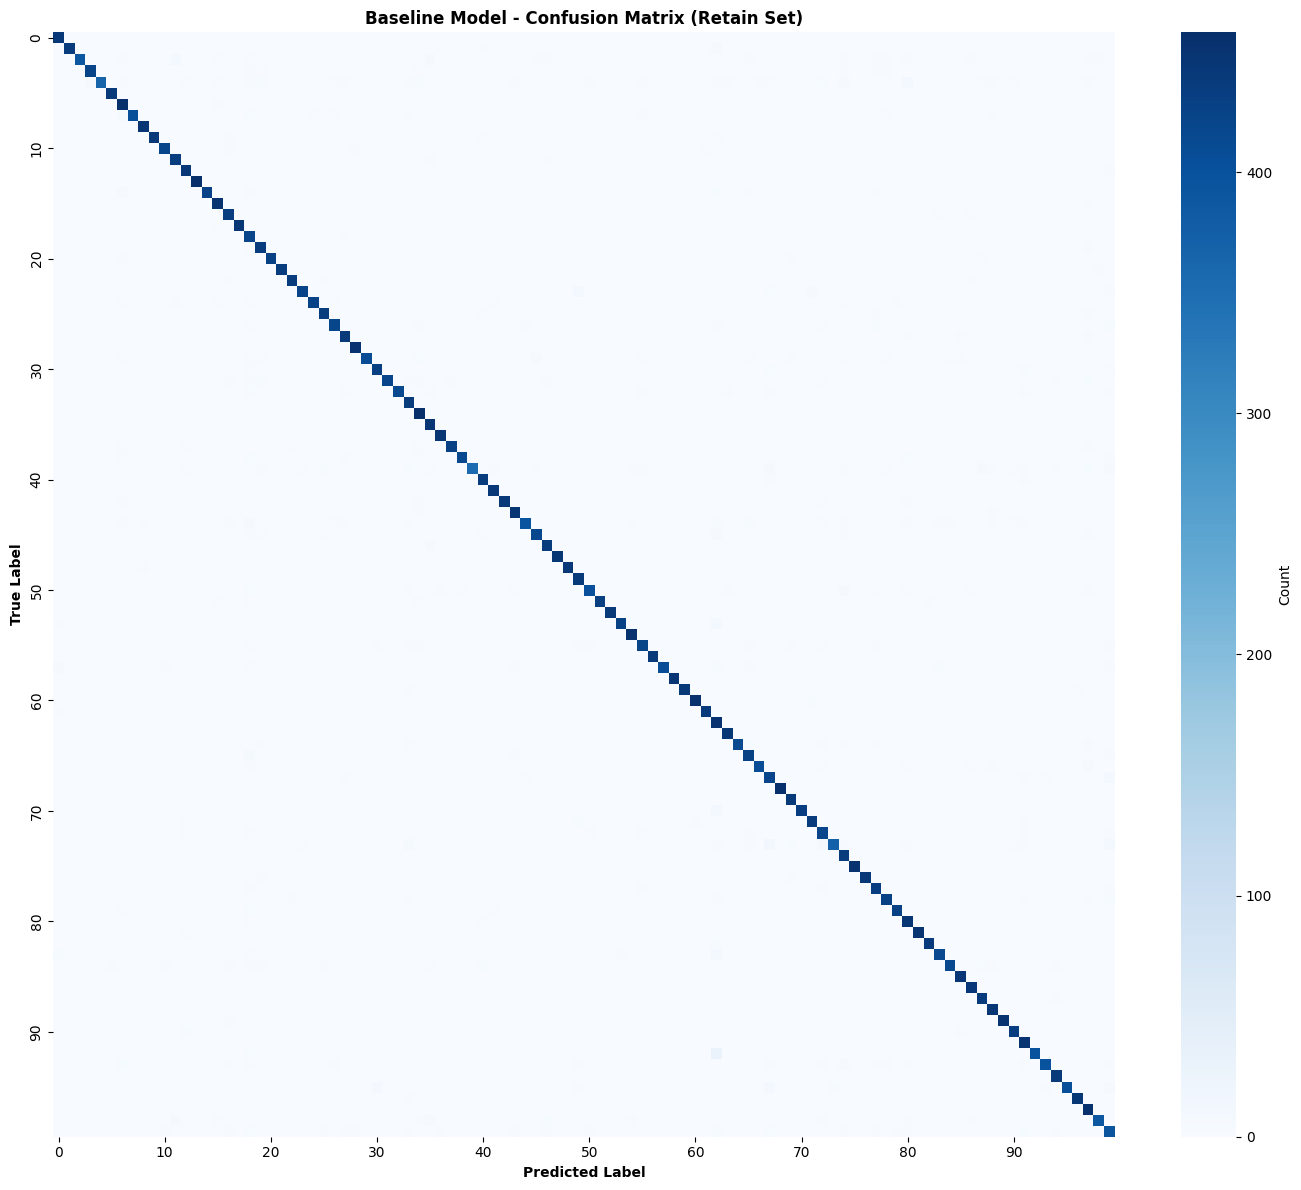

In [247]:
print("\n" + "="*70)
print("BASELINE MODEL - Per-Class Accuracy & Confusion Matrix")
print("="*70)

baseline_cm, baseline_per_class, _, _ = compute_confusion_matrix_and_per_class_metrics(
    baseline_model, retain_loader, device
)

# Display per-class accuracy
print("\nPer-Class Accuracy on RETAIN set:")
print("-" * 40)
for digit in range(100):
    acc = baseline_per_class[digit]
    if acc is not None:
        print(f"  Class {digit}: {acc:.4f}")

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(14, 12))
plot_confusion_matrix(baseline_cm, "Baseline Model - Confusion Matrix (Retain Set)", ax=ax)
plt.tight_layout()
save_plot(fig, "plot_01_baseline_confusion_matrix_retain.png")
plt.show()


EXACT UNLEARNING - Per-Class Accuracy & Confusion Matrix

Per-Class Accuracy on RETAIN set:
----------------------------------------
  Class 0: 0.9933
  Class 1: 0.9618
  Class 2: 0.9181
  Class 3: 0.9397
  Class 4: 0.9667
  Class 5: 0.9932
  Class 6: 0.9978
  Class 7: 0.9844
  Class 8: 0.9978
  Class 9: 0.9538
  Class 10: 0.8649
  Class 11: 0.9933
  Class 12: 0.9888
  Class 13: 0.9630
  Class 14: 0.9272
  Class 15: 0.9782
  Class 16: 0.9888
  Class 17: 0.9978
  Class 18: 0.7080
  Class 19: 0.9621
  Class 20: 0.9909
  Class 21: 0.9865
  Class 22: 0.9782
  Class 23: 0.9824
  Class 24: 0.9823
  Class 25: 0.9537
  Class 26: 0.9711
  Class 27: 0.9666
  Class 28: 0.9757
  Class 29: 0.9846
  Class 30: 0.9933
  Class 31: 0.9913
  Class 32: 0.9495
  Class 33: 0.9864
  Class 34: 0.8807
  Class 35: 0.9051
  Class 36: 0.9933
  Class 37: 0.9821
  Class 38: 0.9843
  Class 39: 0.9683
  Class 40: 0.9284
  Class 41: 1.0000
  Class 42: 0.9761
  Class 43: 0.9801
  Class 44: 0.9176
  Class 45: 0.9530
  

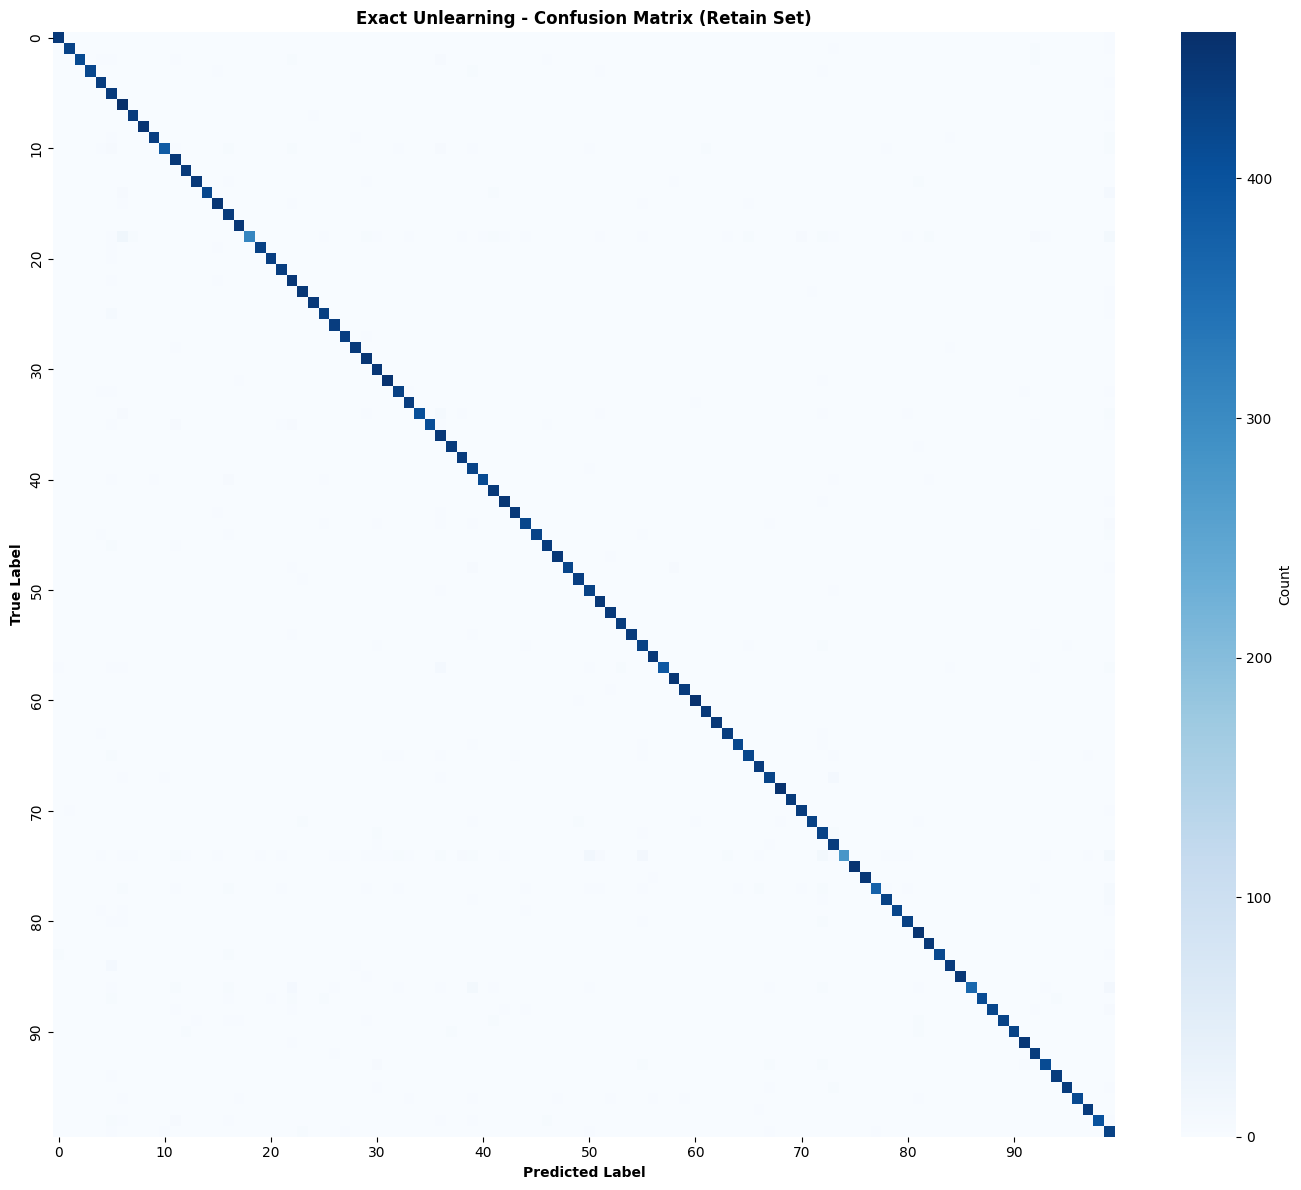

In [248]:
print("\n" + "="*70)
print("EXACT UNLEARNING - Per-Class Accuracy & Confusion Matrix")
print("="*70)

exact_cm, exact_per_class, _, _ = compute_confusion_matrix_and_per_class_metrics(
    exact_model, retain_loader, device
)

# Display per-class accuracy
print("\nPer-Class Accuracy on RETAIN set:")
print("-" * 40)
for digit in range(100):
    acc = exact_per_class[digit]
    if acc is not None:
        print(f"  Class {digit}: {acc:.4f}")

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(14, 12))
plot_confusion_matrix(exact_cm, "Exact Unlearning - Confusion Matrix (Retain Set)", ax=ax)
plt.tight_layout()
save_plot(fig, "plot_02_exact_confusion_matrix_retain.png")
plt.show()


GRADIENT ASCENT UNLEARNING - Per-Class Accuracy & Confusion Matrix

Per-Class Accuracy on RETAIN set:
----------------------------------------
  Class 0: 0.4955
  Class 1: 0.1978
  Class 2: 0.0973
  Class 3: 0.2746
  Class 4: 0.2971
  Class 5: 0.1716
  Class 6: 0.4740
  Class 7: 0.2411
  Class 8: 0.3053
  Class 9: 0.1495
  Class 10: 0.1374
  Class 11: 0.2143
  Class 12: 0.2595
  Class 13: 0.4674
  Class 14: 0.2539
  Class 15: 0.3900
  Class 16: 0.2360
  Class 17: 0.3051
  Class 18: 0.3747
  Class 19: 0.3728
  Class 20: 0.0228
  Class 21: 0.3296
  Class 22: 0.2445
  Class 23: 0.1278
  Class 24: 0.0465
  Class 25: 0.1410
  Class 26: 0.2533
  Class 27: 0.4187
  Class 28: 0.0795
  Class 29: 0.1382
  Class 30: 0.5889
  Class 31: 0.3529
  Class 32: 0.1560
  Class 33: 0.8643
  Class 34: 0.5922
  Class 35: 0.2561
  Class 36: 0.2183
  Class 37: 0.6004
  Class 38: 0.3244
  Class 39: 0.1406
  Class 40: 0.0850
  Class 41: 0.2235
  Class 42: 0.4816
  Class 43: 0.6018
  Class 44: 0.2191
  Class 45:

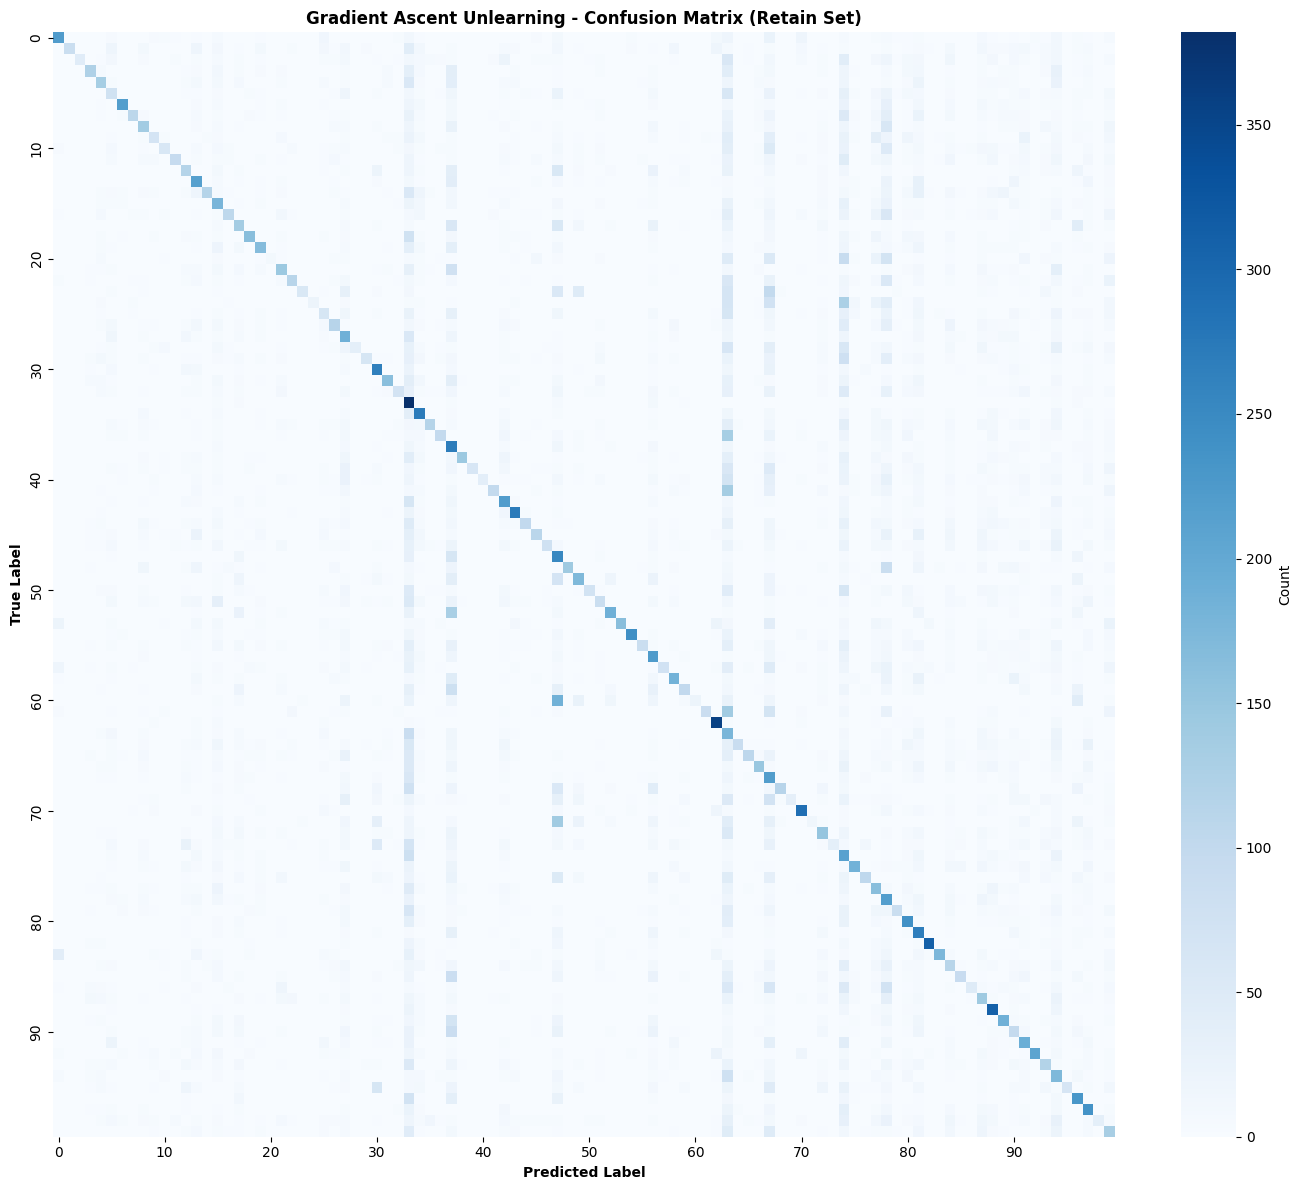

In [249]:
print("\n" + "="*70)
print("GRADIENT ASCENT UNLEARNING - Per-Class Accuracy & Confusion Matrix")
print("="*70)

approx_cm, approx_per_class, _, _ = compute_confusion_matrix_and_per_class_metrics(
    approx_model, retain_loader, device
)

# Display per-class accuracy
print("\nPer-Class Accuracy on RETAIN set:")
print("-" * 40)
for digit in range(100):
    acc = approx_per_class[digit]
    if acc is not None:
        print(f"  Class {digit}: {acc:.4f}")

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(14, 12))
plot_confusion_matrix(approx_cm, "Gradient Ascent Unlearning - Confusion Matrix (Retain Set)", ax=ax)
plt.tight_layout()
save_plot(fig, "plot_03_gradient_ascent_confusion_matrix_retain.png")
plt.show()

In [250]:
print("\n" + "="*70)
print("PER-CLASS ACCURACY COMPARISON (RETAIN SET)")
print("="*70)

def safe_subtract(a, b):
    if a is None or b is None:
        return np.nan
    return a - b

# Create comparison dataframe
comparison_data = {
    'Class': list(range(NUM_CLASSES)),
    'Baseline': [baseline_per_class[d] if baseline_per_class[d] is not None else np.nan for d in range(NUM_CLASSES)],
    'Exact (Retrained)': [exact_per_class[d] if exact_per_class[d] is not None else np.nan for d in range(NUM_CLASSES)],
    'Approx (Grad Ascent)': [approx_per_class[d] if approx_per_class[d] is not None else np.nan for d in range(NUM_CLASSES)],
}

# Add utility loss (drop from baseline to approx)
comparison_data['Utility Loss (Approx)'] = [
    safe_subtract(baseline_per_class[d], approx_per_class[d]) for d in range(NUM_CLASSES)
]

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# Summary statistics
print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"\nAverage per-class accuracy (RETAIN set):")
print(f"  Baseline:              {comparison_df['Baseline'].mean():.4f}")
print(f"  Exact (Retrained):     {comparison_df['Exact (Retrained)'].mean():.4f}")
print(f"  Approx (Grad Ascent):  {comparison_df['Approx (Grad Ascent)'].mean():.4f}")
print(f"\nAverage utility loss:    {comparison_df['Utility Loss (Approx)'].mean():.4f}")
print(f"Max utility loss (most affected class): Class {comparison_df['Utility Loss (Approx)'].idxmax()} ({comparison_df['Utility Loss (Approx)'].max():.4f})")
print(f"Min utility loss (least affected class): Class {comparison_df['Utility Loss (Approx)'].idxmin()} ({comparison_df['Utility Loss (Approx)'].min():.4f})")


PER-CLASS ACCURACY COMPARISON (RETAIN SET)

 Class  Baseline  Exact (Retrained)  Approx (Grad Ascent)  Utility Loss (Approx)
     0  0.991031           0.993274              0.495516               0.495516
     1  0.977528           0.961798              0.197753               0.779775
     2  0.862832           0.918142              0.097345               0.765487
     3  0.946429           0.939732              0.274554               0.671875
     4  0.809313           0.966741              0.297118               0.512195
     5  0.993228           0.993228              0.171558               0.821670
     6  0.991342           0.997835              0.474026               0.517316
     7  0.901786           0.984375              0.241071               0.660714
     8  0.988938           0.997788              0.305310               0.683628
     9  0.967033           0.953846              0.149451               0.817582
    10  0.945946           0.864865              0.137387       

In [251]:
print("\n" + "="*70)
print("DELETE SET PERFORMANCE - Per-Class Accuracy")
print("="*70)
print("\nForgetting Score: How much baseline accuracy decreased per class")
print("(Higher = better forgetting)")

def safe_subtract(a, b):
    if a is None or b is None:
        return np.nan
    return a - b

# Compute per-class metrics on DELETE set
baseline_delete_cm, baseline_delete_pc, _, _ = compute_confusion_matrix_and_per_class_metrics(
    baseline_model, delete_loader, device
)
exact_delete_cm, exact_delete_pc, _, _ = compute_confusion_matrix_and_per_class_metrics(
    exact_model, delete_loader, device
)
approx_delete_cm, approx_delete_pc, _, _ = compute_confusion_matrix_and_per_class_metrics(
    approx_model, delete_loader, device
)

# Create comparison dataframe for DELETE set
delete_comparison_data = {
    'Class': list(range(NUM_CLASSES)),
    'Baseline (Before)': [baseline_delete_pc[d] if baseline_delete_pc[d] is not None else np.nan for d in range(NUM_CLASSES)],
    'Exact (After)': [exact_delete_pc[d] if exact_delete_pc[d] is not None else np.nan for d in range(NUM_CLASSES)],
    'Approx (After)': [approx_delete_pc[d] if approx_delete_pc[d] is not None else np.nan for d in range(NUM_CLASSES)],
}

# Forgetting scores
delete_comparison_data['Forgetting (Exact)'] = [
    safe_subtract(baseline_delete_pc[d], exact_delete_pc[d]) for d in range(NUM_CLASSES)
]
delete_comparison_data['Forgetting (Approx)'] = [
    safe_subtract(baseline_delete_pc[d], approx_delete_pc[d]) for d in range(NUM_CLASSES)
]

delete_comparison_df = pd.DataFrame(delete_comparison_data)
print("\n" + delete_comparison_df.to_string(index=False))

print("\n" + "="*70)
print("DELETE SET SUMMARY")
print("="*70)
print(f"\nAverage per-class accuracy on DELETE set:")
print(f"  Baseline (Before):     {delete_comparison_df['Baseline (Before)'].mean():.4f}")
print(f"  Exact (After):         {delete_comparison_df['Exact (After)'].mean():.4f}")
print(f"  Approx (After):        {delete_comparison_df['Approx (After)'].mean():.4f}")

print(f"\nAverage Forgetting Score:")
print(f"  Exact Method:          {delete_comparison_df['Forgetting (Exact)'].mean():.4f}")
print(f"  Approx Method:         {delete_comparison_df['Forgetting (Approx)'].mean():.4f}")

valid_forgetting = delete_comparison_df['Forgetting (Approx)'].dropna()
if len(valid_forgetting) > 0:
    best_class = int(valid_forgetting.idxmax())
    worst_class = int(valid_forgetting.idxmin())
    print(f"\nBest Forgetting (Approx): Class {best_class} ({valid_forgetting.max():.4f})")
    print(f"Worst Forgetting (Approx): Class {worst_class} ({valid_forgetting.min():.4f})")
else:
    print("\nNo valid per-class forgetting scores available on DELETE set.")


DELETE SET PERFORMANCE - Per-Class Accuracy

Forgetting Score: How much baseline accuracy decreased per class
(Higher = better forgetting)

 Class  Baseline (Before)  Exact (After)  Approx (After)  Forgetting (Exact)  Forgetting (Approx)
     0           1.000000       0.666667        0.592593            0.333333             0.407407
     1           0.909091       0.309091        0.181818            0.600000             0.727273
     2           0.916667       0.145833        0.145833            0.770833             0.770833
     3           0.980769       0.038462        0.365385            0.942308             0.615385
     4           0.897959       0.326531        0.285714            0.571429             0.612245
     5           1.000000       0.385965        0.140351            0.614035             0.859649
     6           1.000000       0.394737        0.421053            0.605263             0.578947
     7           0.884615       0.153846        0.230769            0.73076


CONFUSION MATRIX COMPARISON - All Three Techniques
Saved plot: ../results/plots/CIFAR100_gradient_ascent_and_gold_seed_0042_delete_0p1/plot_04_confusion_matrix_comparison_retain.png


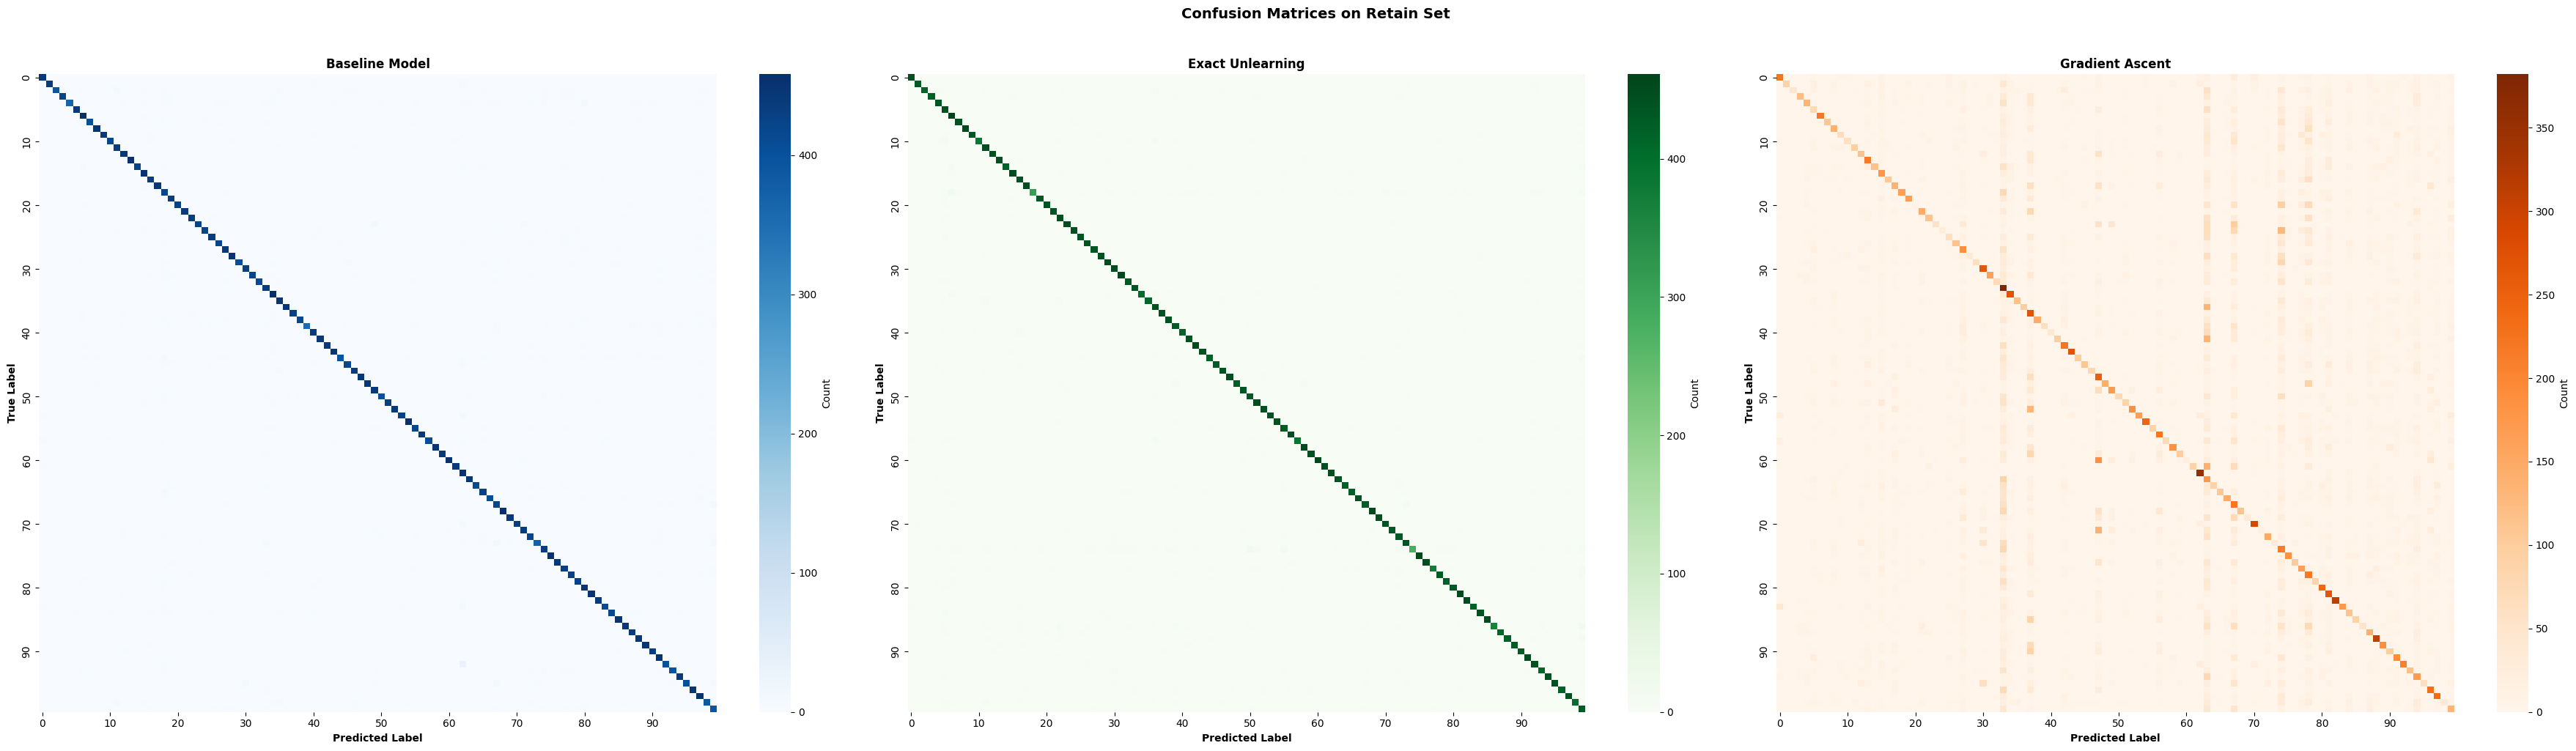

Confusion matrices visualized


In [252]:
print("\n" + "="*70)
print("CONFUSION MATRIX COMPARISON - All Three Techniques")
print("="*70)

# Create side-by-side confusion matrices (RETAIN set)
fig, axes = plt.subplots(1, 3, figsize=(36, 10))

plot_confusion_matrix(baseline_cm, "Baseline Model", ax=axes[0], cmap='Blues')
plot_confusion_matrix(exact_cm, "Exact Unlearning", ax=axes[1], cmap='Greens')
plot_confusion_matrix(approx_cm, "Gradient Ascent", ax=axes[2], cmap='Oranges')

plt.suptitle('Confusion Matrices on Retain Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot(fig, "plot_04_confusion_matrix_comparison_retain.png")
plt.show()

print("Confusion matrices visualized")


PER-CLASS ACCURACY VISUALIZATION (RETAIN SET)
Saved plot: ../results/plots/CIFAR100_gradient_ascent_and_gold_seed_0042_delete_0p1/plot_05_per_class_accuracy_and_utility_loss.png


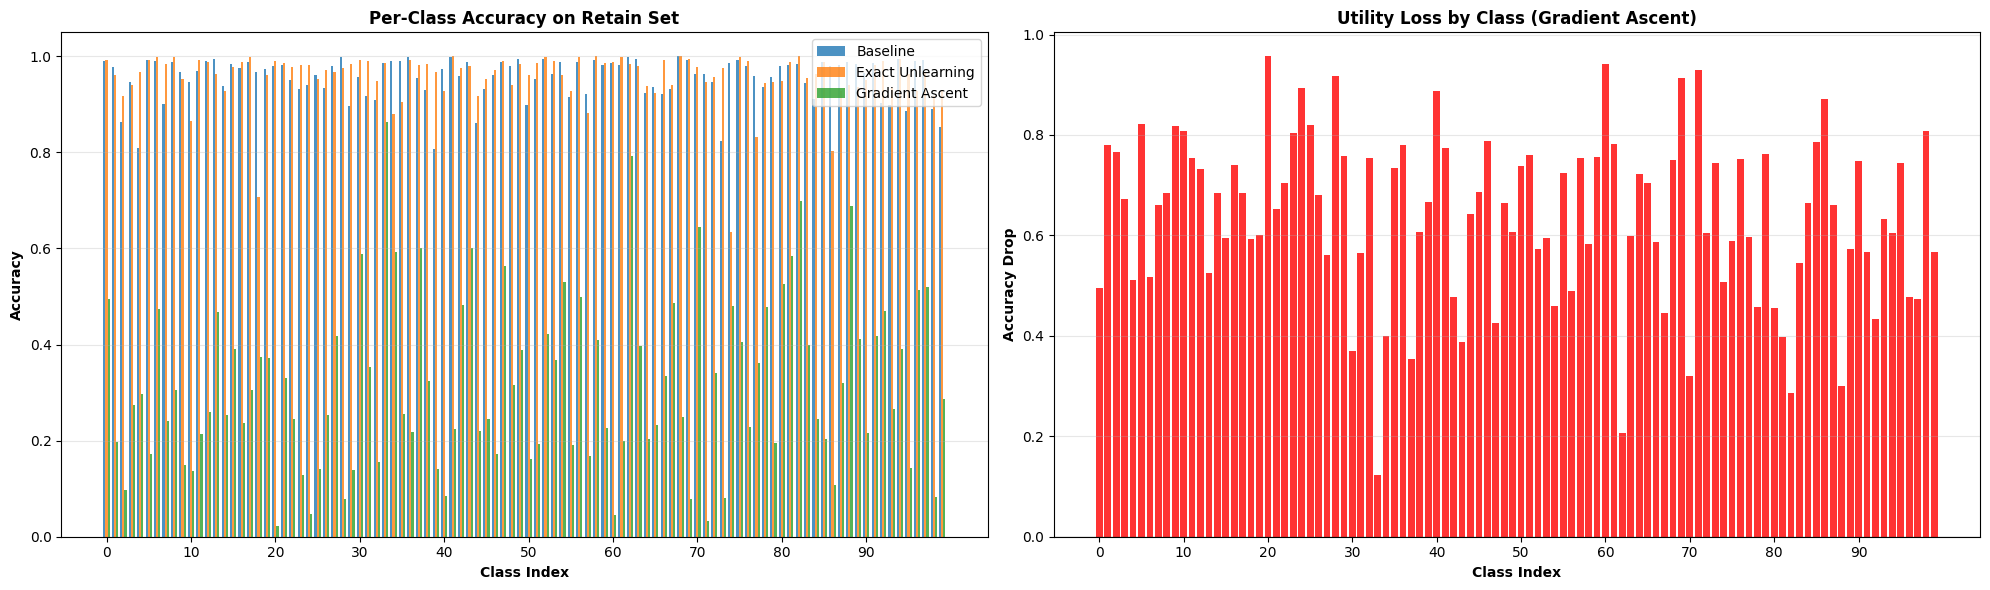

Per-class accuracy visualization complete


In [253]:
print("\nPER-CLASS ACCURACY VISUALIZATION (RETAIN SET)")

# Create bar chart comparing per-class accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot 1: Per-class accuracy for all three methods
classes = list(range(100))
x = np.arange(len(classes))
width = 0.25

baseline_accs = [baseline_per_class[d] for d in range(100)]
exact_accs = [exact_per_class[d] for d in range(100)]
approx_accs = [approx_per_class[d] for d in range(100)]

ax1.bar(x - width, baseline_accs, width, label='Baseline', alpha=0.8)
ax1.bar(x, exact_accs, width, label='Exact Unlearning', alpha=0.8)
ax1.bar(x + width, approx_accs, width, label='Gradient Ascent', alpha=0.8)

ax1.set_xlabel('Class Index', fontweight='bold')
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_title('Per-Class Accuracy on Retain Set', fontweight='bold')
# Show every 10th class label for readability
ax1.set_xticks(x[::10])
ax1.set_xticklabels(classes[::10])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1.05])

# Plot 2: Utility Loss (how much each class dropped with gradient ascent)
utility_losses = [baseline_per_class[d] - approx_per_class[d] for d in range(100)]
colors = ['red' if loss > 0.05 else 'orange' if loss > 0.02 else 'green' for loss in utility_losses]
ax2.bar(classes, utility_losses, color=colors, alpha=0.8)

ax2.set_xlabel('Class Index', fontweight='bold')
ax2.set_ylabel('Accuracy Drop', fontweight='bold')
ax2.set_title('Utility Loss by Class (Gradient Ascent)', fontweight='bold')
# Show every 10th class label for readability
ax2.set_xticks(classes[::10])
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
save_plot(fig, "plot_05_per_class_accuracy_and_utility_loss.png")
plt.show()

print("Per-class accuracy visualization complete")

## Stage 7: Save Results

In [254]:
def to_float_or_none(value):
    return float(value) if value is not None else None


def diff_or_none(a, b):
    if a is None or b is None:
        return None
    return float(a - b)


results = {
    "experiment_info": {
        "timestamp": datetime.now().isoformat(),
        "seed": SEED,
        "dataset": DATASET_TAG,
        "model": "SimpleCNN",
        "deletion_ratio": DELETE_RATIO,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "epochs": TRAIN_EPOCHS,
        "loss": LOSS_NAME,
        "device": str(device),
        "important_note": "Baseline trained on ALL data, then split for evaluation"
    },

    "baseline_model": {
        "train_time_seconds": baseline_train_time,
        "trained_on": f"All {len(train_dataset)} training samples",
        "delete_set_accuracy": float(delete_acc_before),
        "delete_set_loss": float(delete_loss_before),
        "retain_set_accuracy": float(retain_acc_before),
        "test_accuracy": float(test_acc_before),
        "per_class_accuracy": {
            "retain_set": {str(class_idx): to_float_or_none(baseline_per_class[class_idx]) for class_idx in range(NUM_CLASSES)},
            "delete_set": {str(class_idx): to_float_or_none(baseline_delete_pc[class_idx]) for class_idx in range(NUM_CLASSES)},
        },
    },

    "exact_unlearning": {
        "method": "Retrain from scratch on retain set only",
        "train_time_seconds": exact_time,
        "delete_set_accuracy": float(exact_delete_acc),
        "delete_set_loss": float(exact_delete_loss),
        "forgetting_score": float(delete_acc_before - exact_delete_acc),
        "retain_set_accuracy": float(exact_retain_acc),
        "test_accuracy": float(exact_test_acc),
        "per_class_accuracy": {
            "retain_set": {str(class_idx): to_float_or_none(exact_per_class[class_idx]) for class_idx in range(NUM_CLASSES)},
            "delete_set": {str(class_idx): to_float_or_none(exact_delete_pc[class_idx]) for class_idx in range(NUM_CLASSES)},
        },
        "per_class_forgetting_score": {
            str(class_idx): diff_or_none(baseline_delete_pc[class_idx], exact_delete_pc[class_idx]) for class_idx in range(NUM_CLASSES)
        },
    },

    "approx_unlearning": {
        "method": "Gradient ascent on delete set",
        "hyperparameters": {
            "lr": 1e-4,
            "steps": 3,
            "optimizer": "SGD"
        },
        "train_time_seconds": approx_time,
        "delete_set_accuracy": float(approx_delete_acc),
        "delete_set_loss": float(approx_delete_loss),
        "forgetting_score": float(delete_acc_before - approx_delete_acc),
        "retain_set_accuracy": float(approx_retain_acc),
        "utility_loss": float(retain_acc_before - approx_retain_acc),
        "test_accuracy": float(approx_test_acc),
        "per_class_accuracy": {
            "retain_set": {str(class_idx): to_float_or_none(approx_per_class[class_idx]) for class_idx in range(NUM_CLASSES)},
            "delete_set": {str(class_idx): to_float_or_none(approx_delete_pc[class_idx]) for class_idx in range(NUM_CLASSES)},
        },
        "per_class_forgetting_score": {
            str(class_idx): diff_or_none(baseline_delete_pc[class_idx], approx_delete_pc[class_idx]) for class_idx in range(NUM_CLASSES)
        },
        "per_class_utility_loss": {
            str(class_idx): diff_or_none(baseline_per_class[class_idx], approx_per_class[class_idx]) for class_idx in range(NUM_CLASSES)
        },
        "distance_metrics": {
            "l2_absolute": float(abs_l2),
            "l2_relative": float(rel_l2),
            "metric_definition": "Global L2 norm over all parameters"
        },
    },

    "efficiency_comparison": {
        "exact_time_seconds": exact_time,
        "approx_time_seconds": approx_time,
        "speedup_factor": float(exact_time / approx_time) if approx_time > 0 else None,
    },

    "privacy_evaluation_mia": {
        "baseline_model": {
            "mia_accuracy": mia_baseline['mia_accuracy'],
            "tpr": mia_baseline['tpr'],
            "fpr": mia_baseline['fpr'],
        },
        "after_unlearning": {
            "mia_accuracy": mia_approx['mia_accuracy'],
            "tpr": mia_approx['tpr'],
            "fpr": mia_approx['fpr'],
        },
        "privacy_gain": float(privacy_gain),
    },

    "data_split_info": {
        "total_training_samples": len(train_dataset),
        "delete_set_size": len(delete_set),
        "retain_set_size": len(retain_set),
        "test_set_size": len(test_dataset),
        "split_saved_to": split_file,
    }
}

# Create output directories
os.makedirs("../results", exist_ok=True)
os.makedirs("../results/metadata", exist_ok=True)
os.makedirs("../models", exist_ok=True)

# Save model checkpoints
baseline_model_path = f"../models/{DATASET_TAG}_baseline_seed_{SEED:04d}.pt"
gold_model_path = f"../models/{DATASET_TAG}_gold_exact_seed_{SEED:04d}.pt"
approx_model_path = f"../models/{DATASET_TAG}_approx_unlearned_seed_{SEED:04d}.pt"

torch.save(baseline_model.state_dict(), baseline_model_path)
torch.save(exact_model.state_dict(), gold_model_path)
torch.save(approx_model.state_dict(), approx_model_path)

# Add checkpoint paths to results
results["saved_models"] = {
    "baseline_model_path": baseline_model_path,
    "gold_model_path": gold_model_path,
    "approx_model_path": approx_model_path
}

# Save metrics JSON
filename = f"../results/metadata/{DATASET_TAG}_unlearning_seed_{SEED:04d}_{DELETE_RATIO}_results.json"
with open(filename, "w") as f:
    json.dump(results, f, indent=4)

print(f"\n Results saved to: {filename}")
print(f" Data split saved to: {split_file}")
print(f" Baseline model saved to: {baseline_model_path}")
print(f" Gold (exact retrained) model saved to: {gold_model_path}")
print(f" Approx unlearned model saved to: {approx_model_path}")


 Results saved to: ../results/metadata/CIFAR100_unlearning_seed_0042_0.1_results.json
 Data split saved to: ../data_splits/CIFAR100_split_seed_0042.npz
 Baseline model saved to: ../models/CIFAR100_baseline_seed_0042.pt
 Gold (exact retrained) model saved to: ../models/CIFAR100_gold_exact_seed_0042.pt
 Approx unlearned model saved to: ../models/CIFAR100_approx_unlearned_seed_0042.pt
